In [1]:
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn

print("Python Version:", sys.version)
print("SciPy Version:", scipy.__version__)
print("NumPy Version:", numpy.__version__)
print("Matplotlib Version:", matplotlib.__version__)
print("Pandas Version:", pandas.__version__)
print("Scikit-learn Version:", sklearn.__version__)

Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
SciPy Version: 1.16.3
NumPy Version: 2.3.5
Matplotlib Version: 3.10.6
Pandas Version: 2.3.3
Scikit-learn Version: 1.7.2


In [2]:
import importlib

libraries = ["sys", "scipy", "numpy", "matplotlib", "pandas", "sklearn"]

for lib in libraries:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, "__version__", "Built-in / No version")
        print(f"{lib}: {version}")
    except ImportError:
        print(f"{lib}: Not installed")

sys: Built-in / No version
scipy: 1.16.3
numpy: 2.3.5
matplotlib: 3.10.6
pandas: 2.3.3
sklearn: 1.7.2


In [3]:
# Load libraries

import pandas  
# Used for data manipulation and analysis (DataFrames, CSV handling, etc.)

from pandas.plotting import scatter_matrix  
# Used to create scatter plot matrices for visualizing relationships between multiple variables

import matplotlib.pyplot as plt  
# Used for data visualization (plots, charts, graphs)

from sklearn import model_selection  
# Provides tools for splitting data (train/test split), cross-validation, etc.

from sklearn.metrics import classification_report  
# Generates a detailed report of model performance (precision, recall, F1-score)

from sklearn.metrics import confusion_matrix  
# Creates a confusion matrix to evaluate classification accuracy

from sklearn.metrics import accuracy_score  
# Calculates the accuracy of the model (correct predictions / total predictions)

from sklearn.linear_model import LogisticRegression  
# Implements Logistic Regression algorithm (used for classification problems)

from sklearn.tree import DecisionTreeClassifier  
# Decision Tree model for classification tasks

from sklearn.neighbors import KNeighborsClassifier  
# K-Nearest Neighbors (KNN) algorithm for classification

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  
# LDA: used for classification and dimensionality reduction

from sklearn.naive_bayes import GaussianNB  
# Naive Bayes classifier based on Gaussian distribution (fast and simple model)

from sklearn.svm import SVC  
# Support Vector Classifier (SVM) for classification with powerful decision boundaries

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names =['sepal-length','sepal-width','petal-length','petal-width','class']

In [5]:
dataset = pandas.read_csv(url,names=names)

In [6]:
print (dataset.shape)

(150, 5)


In [7]:
print(dataset.head(51))

    sepal-length  sepal-width  petal-length  petal-width            class
0            5.1          3.5           1.4          0.2      Iris-setosa
1            4.9          3.0           1.4          0.2      Iris-setosa
2            4.7          3.2           1.3          0.2      Iris-setosa
3            4.6          3.1           1.5          0.2      Iris-setosa
4            5.0          3.6           1.4          0.2      Iris-setosa
5            5.4          3.9           1.7          0.4      Iris-setosa
6            4.6          3.4           1.4          0.3      Iris-setosa
7            5.0          3.4           1.5          0.2      Iris-setosa
8            4.4          2.9           1.4          0.2      Iris-setosa
9            4.9          3.1           1.5          0.1      Iris-setosa
10           5.4          3.7           1.5          0.2      Iris-setosa
11           4.8          3.4           1.6          0.2      Iris-setosa
12           4.8          3.0         

In [8]:
print(dataset.describe())

       sepal-length  sepal-width  petal-length  petal-width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [9]:
print(dataset.groupby('class').size())

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


In [10]:
## univaried plots

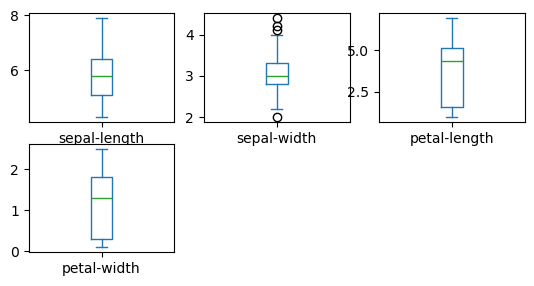

In [11]:
dataset.plot(kind='box', subplots = True, layout = (3,3), sharex=False, sharey = False)
plt.show()

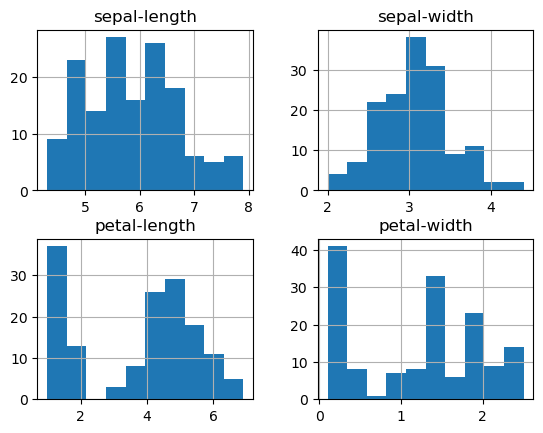

In [12]:
dataset.hist()
plt.show()

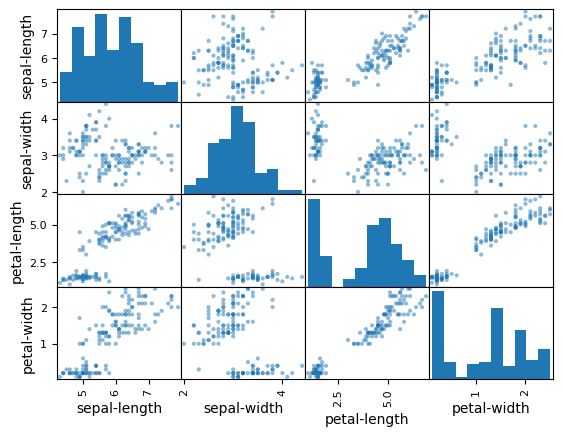

In [13]:
scatter_matrix(dataset)
plt.show()

In [14]:
array = dataset.values
x = array[:,0:4]
y = array[ : ,4 ]
validation_size = 0.20
seed = 6
x_train, x_test, y_train , y_test = model_selection.train_test_split(x, y, test_size = validation_size , random_state = seed)



In [15]:
seed = 6 
scoring = 'accuracy'

In [16]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART',DecisionTreeClassifier()))
models.append(('NB',GaussianNB()))
models.append(('SVM' , SVC()))

#evaluate each mocel in turn 
results = []
names = []
for name, model in models:
    kfold = model_selection.KFold(n_splits = 10, shuffle = True, random_state = seed)
    cv_results = model_selection.cross_val_score(model, x_train, y_train , cv=kfold, scoring = scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.958333 (0.041667)
LDA: 0.975000 (0.038188)
KNN: 0.958333 (0.041667)
CART: 0.958333 (0.041667)
NB: 0.966667 (0.040825)
SVM: 0.941667 (0.053359)


# understanding the Linear regression model

### main goal is to construct an efficient model to predict the dependent attributes from a bunch of attribute variables 

it is effective when the output variable is either real or a continous value i.e, salary , weight etc

we can also define regression as statical mean that is used in applications like housing , investing , etc. it is used to predict the relationship between a dependent variable and a bunch of independent variable 


types of regression models are 
1. simple regression 
2. polynomial regression 
3. support vector regression 
4. Decision tree regression
5. random forest regression
6. logistic regression

Simple Linear regression 
one of the most common technique wehere we predict the outcome of a depemdemt variable based on the independent variables,the relationship of the variable  is linear


polynomial regression is the regression technique where we transform the original features into the polynomial and then perform regression 

support vector machine regression is the regression technique where we identify the hyperplane with maximum margin such as the maximum number if the data points are within those margins . it is quite simmilar to the support vector machine classification

decisino tree regression it can be used for both regression and classification . in the case of regression , we use the id3 algorithim to identify the apitting node by reducing the standad deviation

Decision tree regression is the collection of the sveral different types of decision tree regressions 

## cost functions
provides the best value of bo and b1 to make the best fit line out of the data points 


formula for the cost function 
## y = b0+b1x+e

y = dependent variable 
b0 = y intercept 
b1 = slope
x = independent variable
e = error

## Gradient decent 
it is the method to update the values of b0 and b1 to reduce the mse (mean square error )
keep iterating the b0 and b1 values untill we reduce the mse to the minimum 

In [17]:
import pandas as pd
df = pd.read_csv(r'C:\Users\hp\Downloads\archive (3)\TD.csv')

In [18]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [19]:
print(df.head(31))

    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   
11           12         1       1   
12           13         0       3   
13           14         0       3   
14           15         0       3   
15           16         1       2   
16           17         0       3   
17           18         1       2   
18           19         0       3   
19           20         1       3   
20           21         0       2   
21           22         1       2   
22           23         1       3   
23           24         1       1   
24           25         0       3   
25           26         1       3   
2

In [20]:
df.head(31)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [21]:
print ('# of passangers in original data: ' +str(len(df)))

# of passangers in original data: 891


In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df_fill = df[df['Survived']==1]

In [24]:
df_fill.head(31)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C


<Axes: xlabel='survived', ylabel='count'>

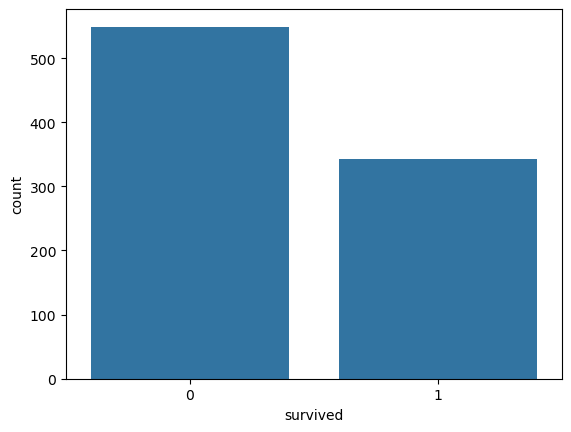

In [25]:
import seaborn as sns


titanic = sns.load_dataset('titanic')
# Create the countplot with the correct column name 'survived' (lowercase)
sns.countplot(x="survived", data=titanic)

<Axes: xlabel='survived', ylabel='count'>

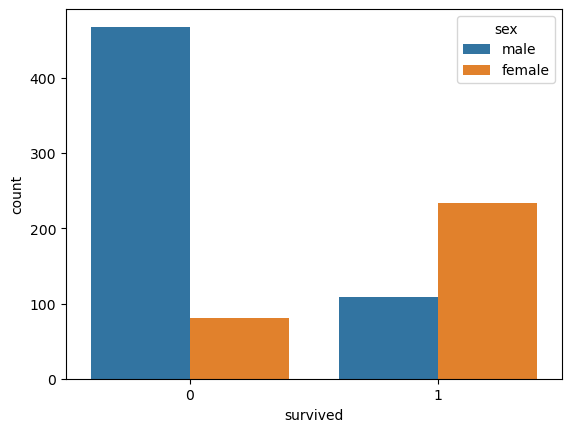

In [26]:
sns.countplot(x="survived", hue="sex", data=titanic)

In [27]:
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='survived', ylabel='count'>

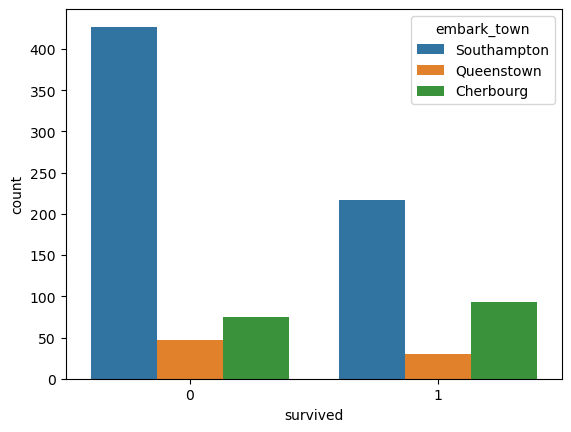

In [28]:
sns.countplot(x = "survived" , hue = "embark_town" , data=titanic)

<Axes: xlabel='survived', ylabel='count'>

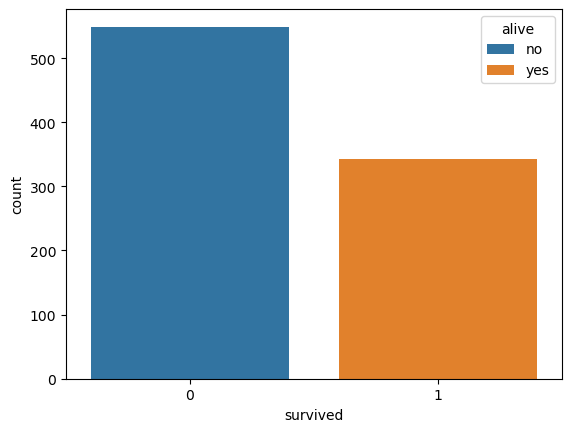

In [29]:
sns.countplot(x = "survived" , hue ="alive" , data = titanic)

<Axes: ylabel='Frequency'>

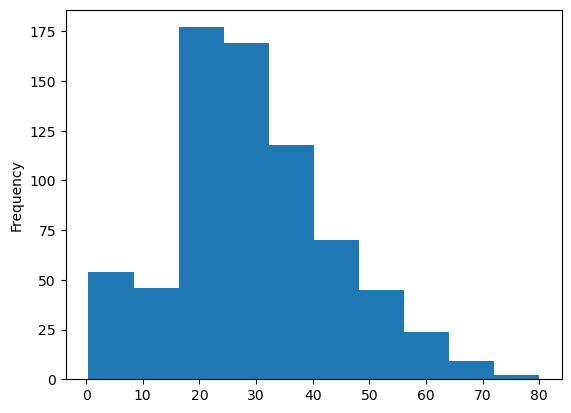

In [30]:
titanic["age"].plot.hist()

<Axes: ylabel='Frequency'>

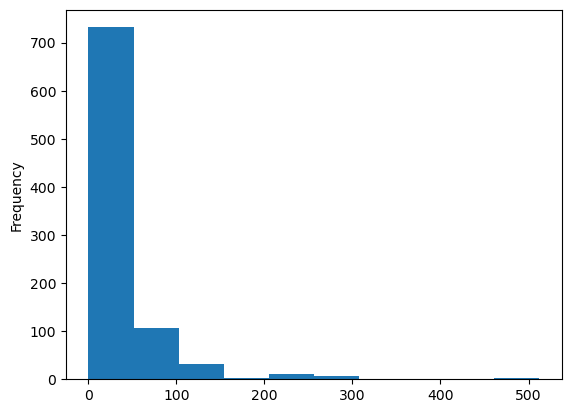

In [31]:
titanic["fare"].plot.hist()

In [32]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


<Axes: xlabel='survived', ylabel='count'>

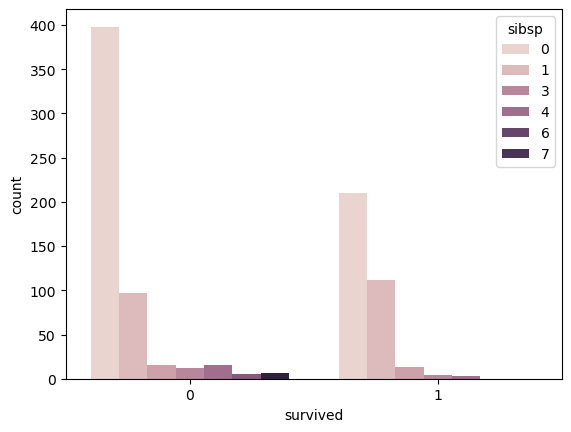

In [33]:
sns.countplot(x = "survived" , hue = "sibsp" , data = titanic)

<Axes: xlabel='sibsp', ylabel='count'>

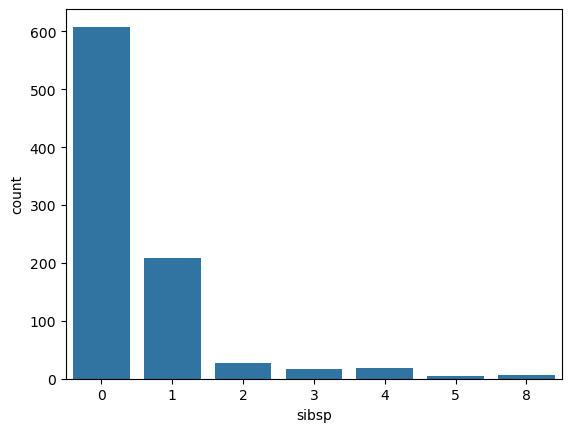

In [34]:
sns.countplot(x="sibsp" , data = titanic)

<Axes: xlabel='survived', ylabel='count'>

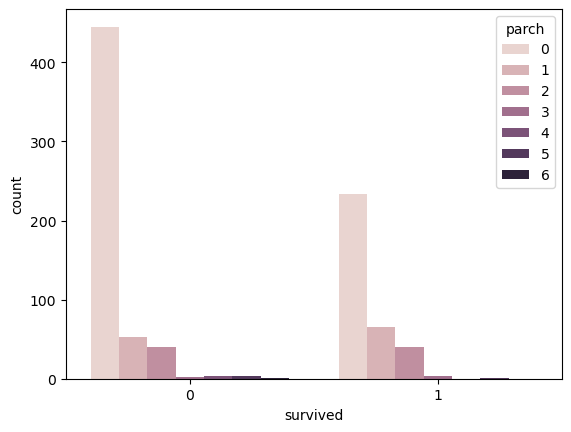

In [35]:
sns.countplot(x = "survived" , hue = "parch" , data = titanic)

<Axes: xlabel='parch', ylabel='count'>

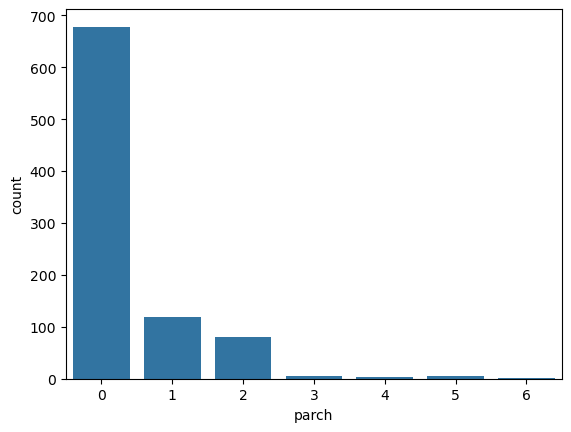

In [36]:
sns.countplot(x = "parch" , data = titanic)

data wrangling or cleaning the data 

In [37]:
titanic.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [38]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: >

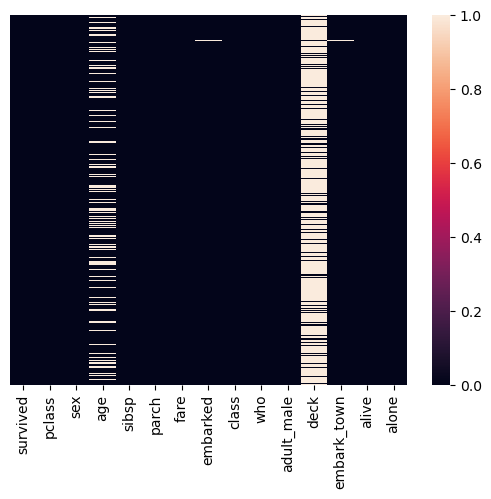

In [39]:
sns.heatmap(titanic.isnull(),yticklabels = False)

<Axes: xlabel='pclass', ylabel='age'>

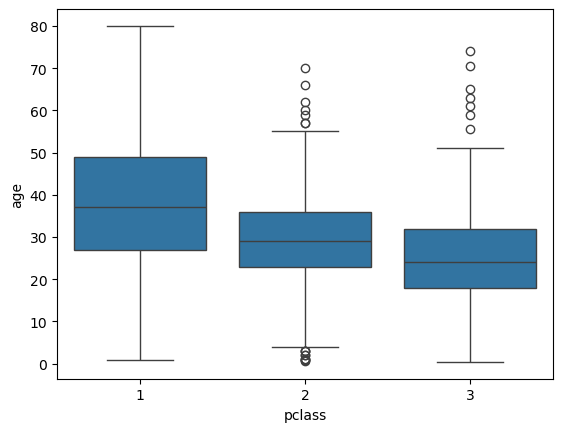

In [40]:
sns.boxplot(x = "pclass" , y = "age" , data = titanic)

In [41]:
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [42]:
titanic.drop("deck" , axis = 1 , inplace = True)

In [43]:
print(titanic.shape,"\n")
titanic.head(5)

(891, 14) 



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [44]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

In [45]:
titanic.dropna(inplace = True)

In [46]:
print(titanic.shape,"\na")
print(titanic.isnull().sum())

(712, 14) 
a
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


<Axes: >

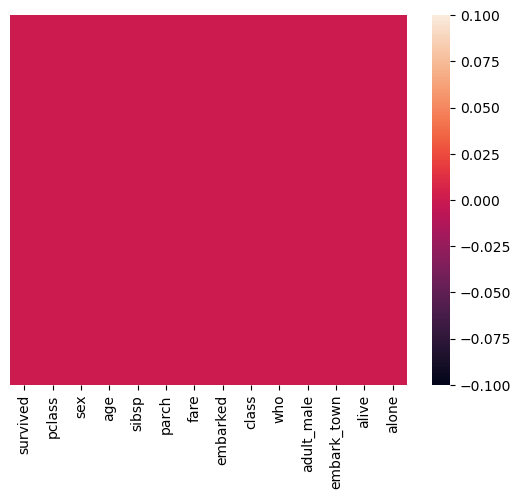

In [47]:
sns.heatmap(titanic.isnull() , yticklabels = False)

In [48]:
sex = pd.get_dummies(titanic['sex'],drop_first=True)
sex.head(5)

,male
0,True
1,False
2,False
3,False
4,True


In [49]:
titanic.embarked.unique()

array(['S', 'C', 'Q'], dtype=object)

In [50]:
embarked= pd.get_dummies(titanic["embarked"],drop_first = True)
embarked.head(5)

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [51]:
pclass = pd.get_dummies(titanic["pclass"] , drop_first=True)
pclass.head(21)

,2,3
0,False,True
1,False,False
2,False,True
3,False,False
4,False,True
6,False,False
7,False,True
8,False,True
9,True,False
10,False,True


In [52]:
titanic= pd.concat([titanic,sex,embarked,pclass], axis =1)

In [53]:
titanic.head(6)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,male,Q,S,2,3
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,True,False,True,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,False,False,False,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False,False,True,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False,False,True,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,True,False,True,False,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,True,False,True,False,False


<Axes: xlabel='survived', ylabel='count'>

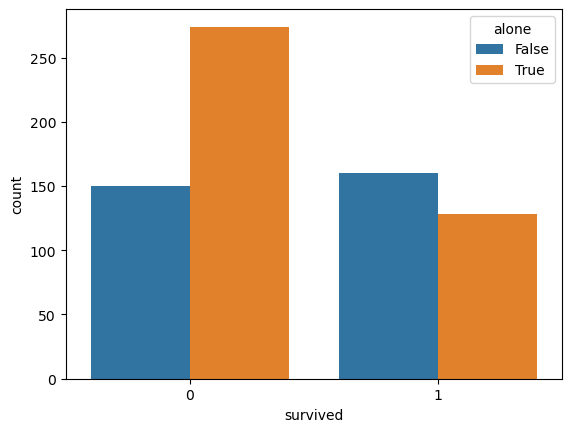

In [54]:
sns.countplot(x="survived" , hue = "alone" , data=titanic )

<Axes: xlabel='alone', ylabel='count'>

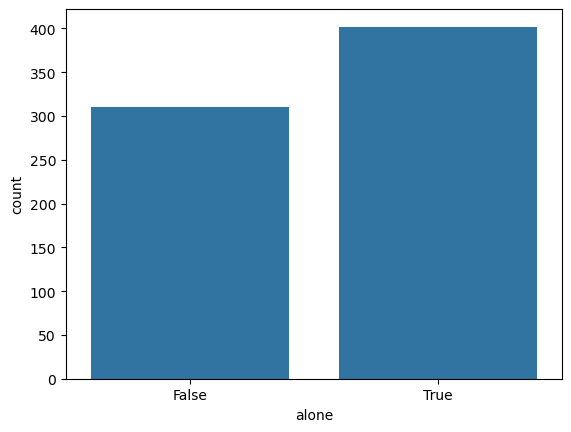

In [55]:
sns.countplot(x="alone" , data=titanic )

In [56]:
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,male,Q,S,2,3
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,True,False,True,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,False,False,False,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False,False,True,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False,False,True,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,True,False,True,False,True


In [57]:
titanic.drop(['sex','embarked','class','pclass','who','adult_male','embark_town','alive','alone'] , axis =1 , inplace =True)

In [58]:
titanic .head(11)

,survived,age,sibsp,parch,fare,male,Q,S,2,3
0,0,22.0,1,0,7.2500,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True
6,0,54.0,0,0,51.8625,True,False,True,False,False
7,0,2.0,3,1,21.0750,True,False,True,False,True
8,1,27.0,0,2,11.1333,False,False,True,False,True
9,1,14.0,1,0,30.0708,False,False,False,True,False
10,1,4.0,1,1,16.7000,False,False,True,False,True


## training and testing the dataset 

logistic=LogisticRegression()
logistic.fit(train_X,train_Y)

In [59]:
x=titanic.drop("survived",axis=1)
y=titanic["survived"]


In [60]:
from sklearn.model_selection import train_test_split
if hasattr(x, 'columns'):
    x.columns = x.columns.astype(str)

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.linear_model import LogisticRegression


In [63]:
logmodel=LogisticRegression()


In [64]:
logmodel.fit(x_train, y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:
predictions = logmodel.predict(x_test)

In [66]:
from sklearn.metrics import classification_report

In [67]:
classification_report(y_test,predictions)

'              precision    recall  f1-score   support\n\n           0       0.78      0.91      0.84        80\n           1       0.86      0.68      0.76        63\n\n    accuracy                           0.81       143\n   macro avg       0.82      0.80      0.80       143\nweighted avg       0.82      0.81      0.81       143\n'

In [68]:
from sklearn.metrics import confusion_matrix

In [69]:
confusion_matrix(y_test,predictions)

array([[73,  7],
       [20, 43]])

In [70]:
accuracy_score(y_test,predictions)

0.8111888111888111